In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import wordcloud 
import sklearn
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer


/home/giulia-mezaroba/Faculdade-Codigos/Cyber-Threat-Dataset-with-Transformers/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


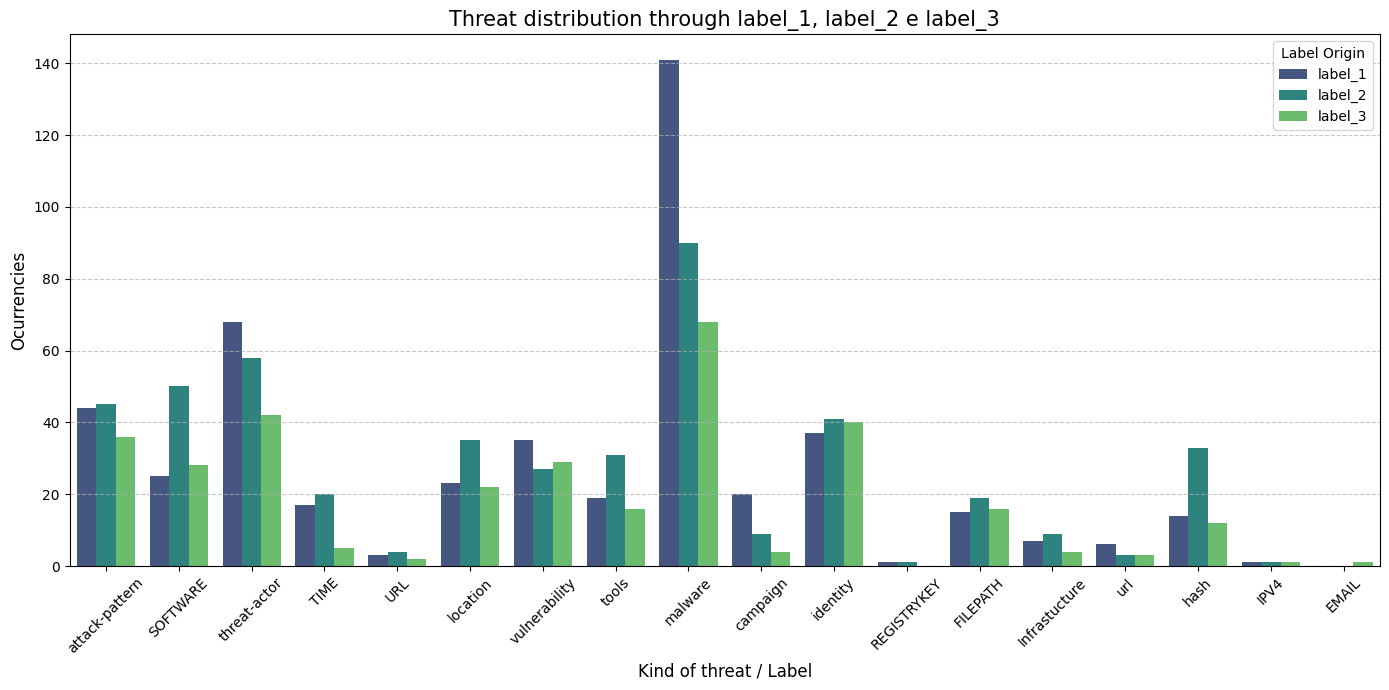

In [ ]:
#Distribution labels
df = pd.read_csv('../data/raw/rawdataset.csv')
label_cols = ['label_1', 'label_2', 'label_3']
df_long = df.melt(value_vars=label_cols, var_name='Column_Label', value_name='Threat')

plt.figure(figsize=(14, 7))
sns.countplot(data=df_long, x='Threat', hue='Column_Label', palette='viridis')

plt.title('Threat distribution through label_1, label_2 and label_3', fontsize=15)
plt.xlabel('Kind of threat / Label', fontsize=12)
plt.ylabel('Ocurrencies', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Label Origin')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:

df['all_labels'] = df[['label_1', 'label_2', 'label_3']].values.tolist()
df['all_labels'] = df['all_labels'].apply(lambda x: [i for i in x if str(i) != 'nan'])

mlb = MultiLabelBinarizer()
labels_binarized = mlb.fit_transform(df['all_labels'])
df_labels = pd.DataFrame(labels_binarized, columns=mlb.classes_)

/tmp/ipykernel_19517/1902505356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frequency.values, y=frequency.index, palette='magma')


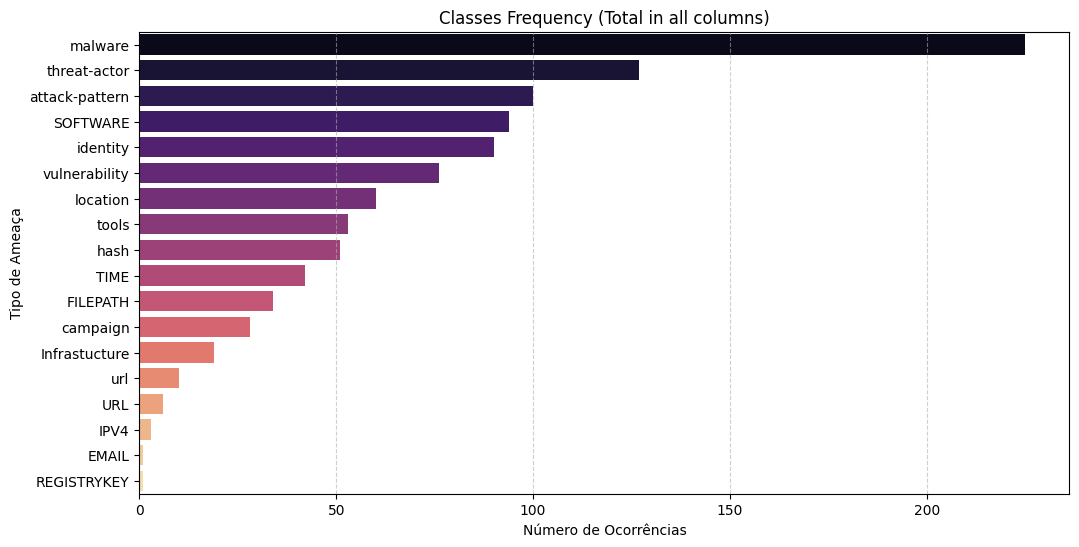

In [ ]:
#labels frequency   
frequency = df_labels.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=frequency.values, y=frequency.index, palette='magma')
plt.title('Classes Frequency (Total in all columns)')
plt.xlabel('Occurency Number')
plt.ylabel('Kind of Threat')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

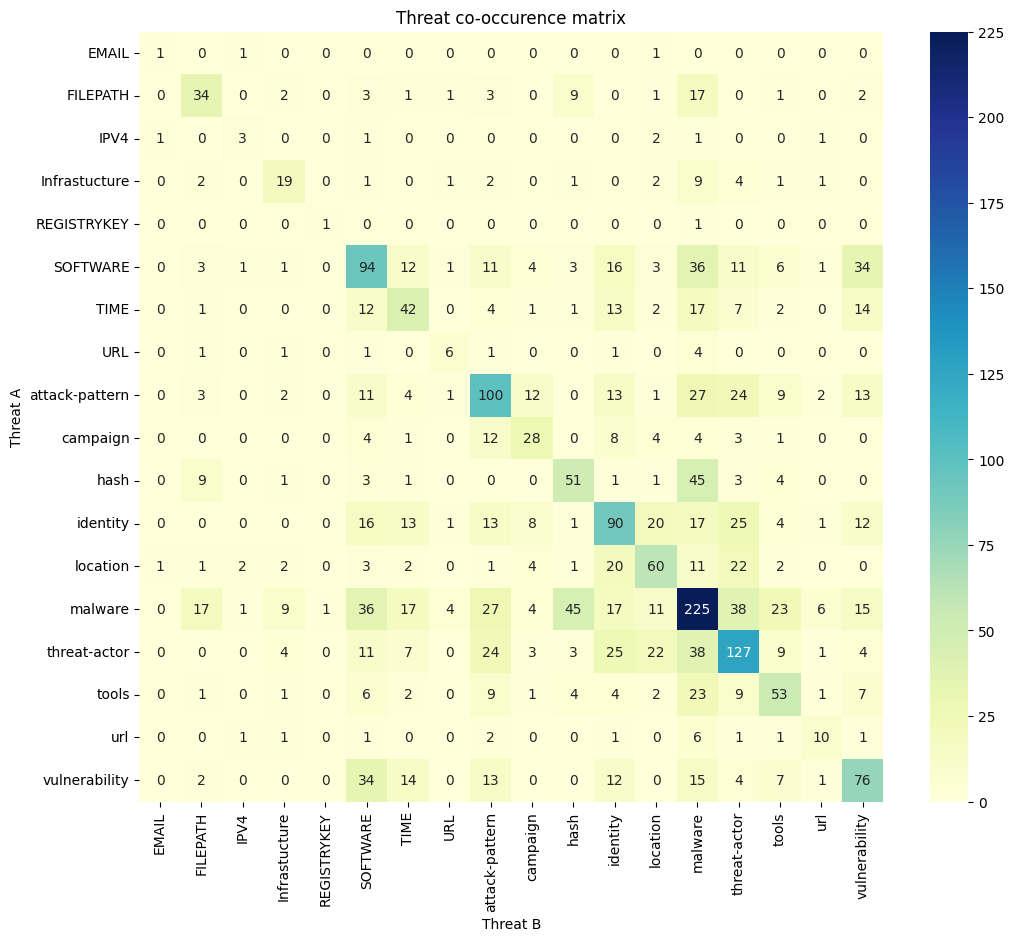

In [ ]:
# Co-occurence matrix (Dot product of the binary matrix)
co_occurrence_matrix = df_labels.T.dot(df_labels)

#Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title('Threat co-occurence matrix')
plt.xlabel('Threat B')
plt.ylabel('Threat A')
plt.show()

       char_count  word_count  token_count
count  476.000000  476.000000   476.000000
mean   190.752101   26.025210    51.042017
std    108.919504   13.249484    46.891076
min     39.000000    2.000000    12.000000
25%    127.750000   17.000000    29.000000
50%    170.000000   24.000000    41.000000
75%    227.000000   33.250000    58.000000
max    889.000000  100.000000   465.000000

Text over 1024 tokens: 0 (0.00%)


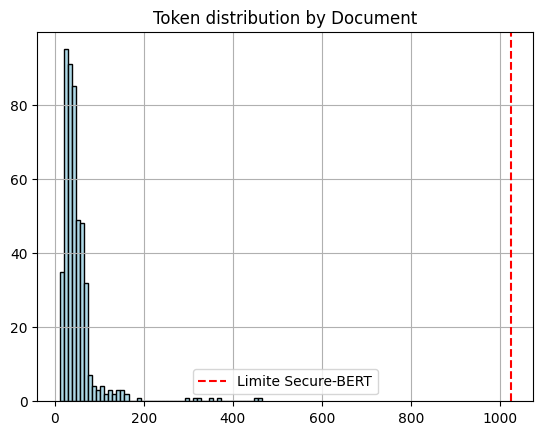

In [23]:
tokenizer = AutoTokenizer.from_pretrained("cisco-ai/SecureBERT2.0-base")

def length_analysis(df, text_column):
    df['char_count'] = df[text_column].str.len()
    df['word_count'] = df[text_column].str.split().str.len()
    
    # token couting for Secure-BERT
    df['token_count'] = df[text_column].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

    # Statistics
    print(df[['char_count', 'word_count', 'token_count']].describe())
    
    # Verify over limit texts
    surplus = df[df['token_count'] > 1024]
    print(f"\nText over 1024 tokens: {len(surplus)} ({len(surplus)/len(df)*100:.2f}%)")

    # Plot
    df['token_count'].hist(bins=50, color='lightblue', edgecolor='black')
    plt.axvline(1024, color='red', linestyle='--', label='Limite Secure-BERT')
    plt.title('Token distribution by Document')
    plt.legend()
    plt.show()

length_analysis(df, 'text')

/tmp/ipykernel_19517/994498530.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Ngram', data=df_bigrams, palette='magma')


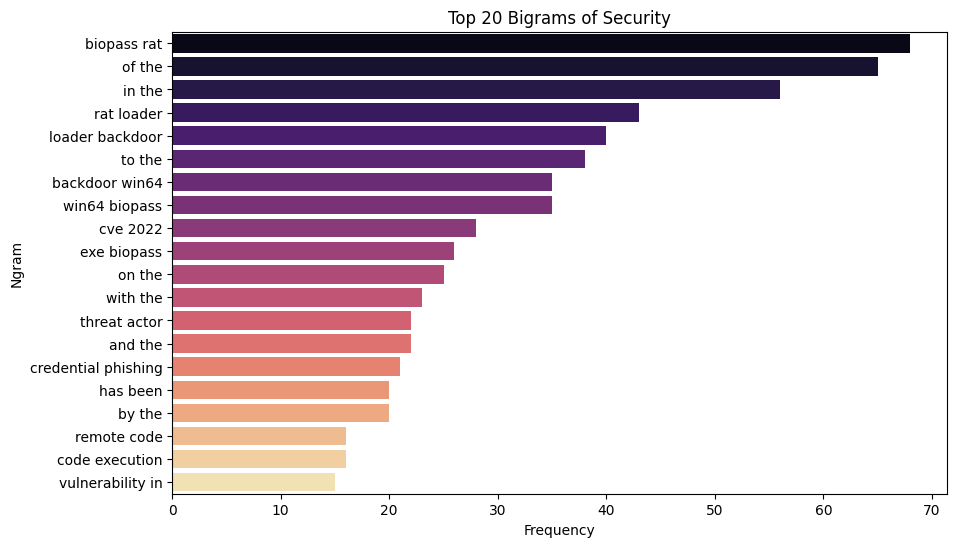

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

def extract_ngrams(df, text_column, n=2):
    # Use CountVectorizer to extract n-grams
    vec = CountVectorizer(ngram_range=(n, n)).fit(df[text_column])
    bag_of_words = vec.transform(df[text_column])
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    
    return words_freq[:20]

top_bigrams = extract_ngrams(df, 'text', n=2)
df_bigrams = pd.DataFrame(top_bigrams, columns=['Ngram', 'Frequency'])

plt.figure(figsize=(10,6))
sns.barplot(x='Frequency', y='Ngram', data=df_bigrams, palette='magma')
plt.title('Top 20 Bigrams of Security')
plt.show()

In [25]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

#whitelist
security_whitelist = {
    'deny', 'allow', 'block', 'critical', 'high', 'low', 'medium', 
    'attack', 'threat', 'vulnerability', 'exploit', 'remote', 'local',
    'access', 'unauthorized', 'command', 'injection', 'buffer', 'overflow'
}

#Stopwords
custom_stopwords = stop_words - security_whitelist

def common_word_analysis(df, text_column):
    all_words = ' '.join(df[text_column]).lower().split()
    security_terms_found = [w for w in all_words if w in security_whitelist]
    
    from collections import Counter
    counts = Counter(security_terms_found)
    
    print("Critical Security Therms Frequency:")
    print(counts.most_common(10))

common_word_analysis(df, 'text')

[nltk_data] Downloading package stopwords to /home/giulia-
[nltk_data]     mezaroba/nltk_data...


Critical Security Therms Frequency:
[('threat', 49), ('vulnerability', 46), ('remote', 26), ('attack', 23), ('exploit', 14), ('access', 13), ('allow', 5), ('critical', 5), ('local', 4), ('command', 4)]


[nltk_data]   Unzipping corpora/stopwords.zip.
